# The Training Loop: Gradient Descent to Minibatches

We have a network (chapter 00) and gradients (chapter 01). Training is the five-line loop
that connects them — the same five lines that later train your capstone LLM:

```python
for step in range(n_steps):
    loss = compute_loss(model, batch)   # forward
    model.zero_grad()                   # reset accumulators
    loss.backward()                     # backprop (chapter 01)
    for p in model.parameters():
        p.data -= lr * p.grad           # descend
```

### Concepts covered

| # | Concept | What to watch for |
|---|---------|-------------------|
| 1 | Gradient descent | Downhill in N-dimensional weight space, one small step at a time |
| 2 | Learning rate | Too small: crawling; too large: divergence — the loss curve shows both |
| 3 | zero_grad | Chapter 01's `grad +=` means stale gradients unless you reset |
| 4 | Minibatch SGD | Noisy gradient estimates, cheaper steps — and it *works* |
| 5 | Loss curve | The training run's vital sign, read constantly from here on |

Reference: [docs/PAPERS.md](../../docs/PAPERS.md) · the production version of this loop:
[`src/ai_playground/training/trainer.py`](https://github.com/ggreg/ai_playground/blob/main/src/ai_playground/training/trainer.py)

::: {.callout-tip title="📺 Video companion"}
[Gradient descent, how neural networks learn (3Blue1Brown)](https://www.youtube.com/watch?v=IHZwWFHWa-w)
animates exactly this chapter — more in [Videos](../../docs/VIDEOS.md).
:::

::: {.callout-note title="🎯 Goal — why this chapter, for the capstone"}
`src/ai_playground/training/trainer.py` — the `Trainer` that runs your capstone model's
first real training at milestone M4 — is this chapter's loop plus refinements you'll meet
one at a time in Phase 2: AdamW is a smarter step rule (chapter 2.4), warmup+cosine is the
learning rate as a function of step (2.1), gradient accumulation is minibatch bookkeeping
under a memory budget (2.3), mixed precision is the same arithmetic in fewer bits (2.2).

Train the loop here at a scale where you can watch every step, and none of those chapters
will feel new — each is one line of this loop, upgraded.

🏗️ **Chapter milestone:** none — M0 lands in the
[next chapter](03_softmax_crossentropy.ipynb), using this loop verbatim.
:::

<a href="https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/00_dnn_refresher/02_training_loop.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

In [1]:
#| code-fold: true
#| code-summary: "Setup"
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

%config InlineBackend.figure_format = 'retina'
from ai_playground.plotting import apply_plot_style
apply_plot_style()

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from ai_playground.fundamentals import MLP, make_moons, plot_decision_boundary

## 1. The model, walked through

`ai_playground.fundamentals.nn` assembles chapter 01's `Value` into chapter 00's
architecture: a `Neuron` is `w·x + b` through an activation, a `Layer` is a list of
neurons (one matmul row each), an `MLP` is a list of layers with a **linear** last layer
so it emits raw scores. `MLP(2, [8, 1])` = 33 parameters:

In [3]:
model = MLP(2, [8, 1], seed=1)
n_params = len(model.parameters())
print(f'MLP(2, [8, 1]): {n_params} parameters  ((2+1)*8 + (8+1)*1 = {(2+1)*8 + (8+1)*1})')
print('Every one is a Value — nudge any of them and loss.backward() prices the nudge.')

# One detail worth pausing on: these Linear layers HAVE biases, while the repo's
# transformer uses bias=False everywhere. The LLM convention works because RMSNorm
# absorbs the shift; with no normalization and 2D inputs, a bias-free neuron's line
# must pass through the origin — and the moons below become unlearnable.

MLP(2, [8, 1]): 33 parameters  ((2+1)*8 + (8+1)*1 = 33)
Every one is a Value — nudge any of them and loss.backward() prices the nudge.


## 2. Full-batch gradient descent

The task: the two moons from chapter 00, targets mapped to ±1, mean-squared error on a
tanh-squashed output. (Deliberately *not* cross-entropy — the next chapter shows why CE
is the better loss for classification. MSE keeps this chapter about the *loop*.)

In [4]:
X, y = make_moons(n=100, noise=0.1, seed=0)
targets = 2.0 * y - 1.0                     # {0,1} -> {-1,+1} to pair with tanh

def batch_loss(model, X, targets):
    total = sum((model([*xi]).tanh() - float(ti)) ** 2 for xi, ti in zip(X, targets))
    return total / len(X)

model = MLP(2, [8, 1], seed=1)
losses = []
t0 = time.perf_counter()
for step in range(201):
    loss = batch_loss(model, X, targets)
    losses.append(loss.data)
    model.zero_grad()                       # chapter 01: grads accumulate unless reset
    loss.backward()
    for p in model.parameters():
        p.data -= 0.5 * p.grad              # lr = 0.5
scalar_seconds = time.perf_counter() - t0
print(f'loss: {losses[0]:.4f} -> {losses[-1]:.4f}   '
      f'({len(losses) - 1} steps in {scalar_seconds:.1f}s on the scalar engine)')

loss: 0.5765 -> 0.0458   (200 steps in 7.4s on the scalar engine)


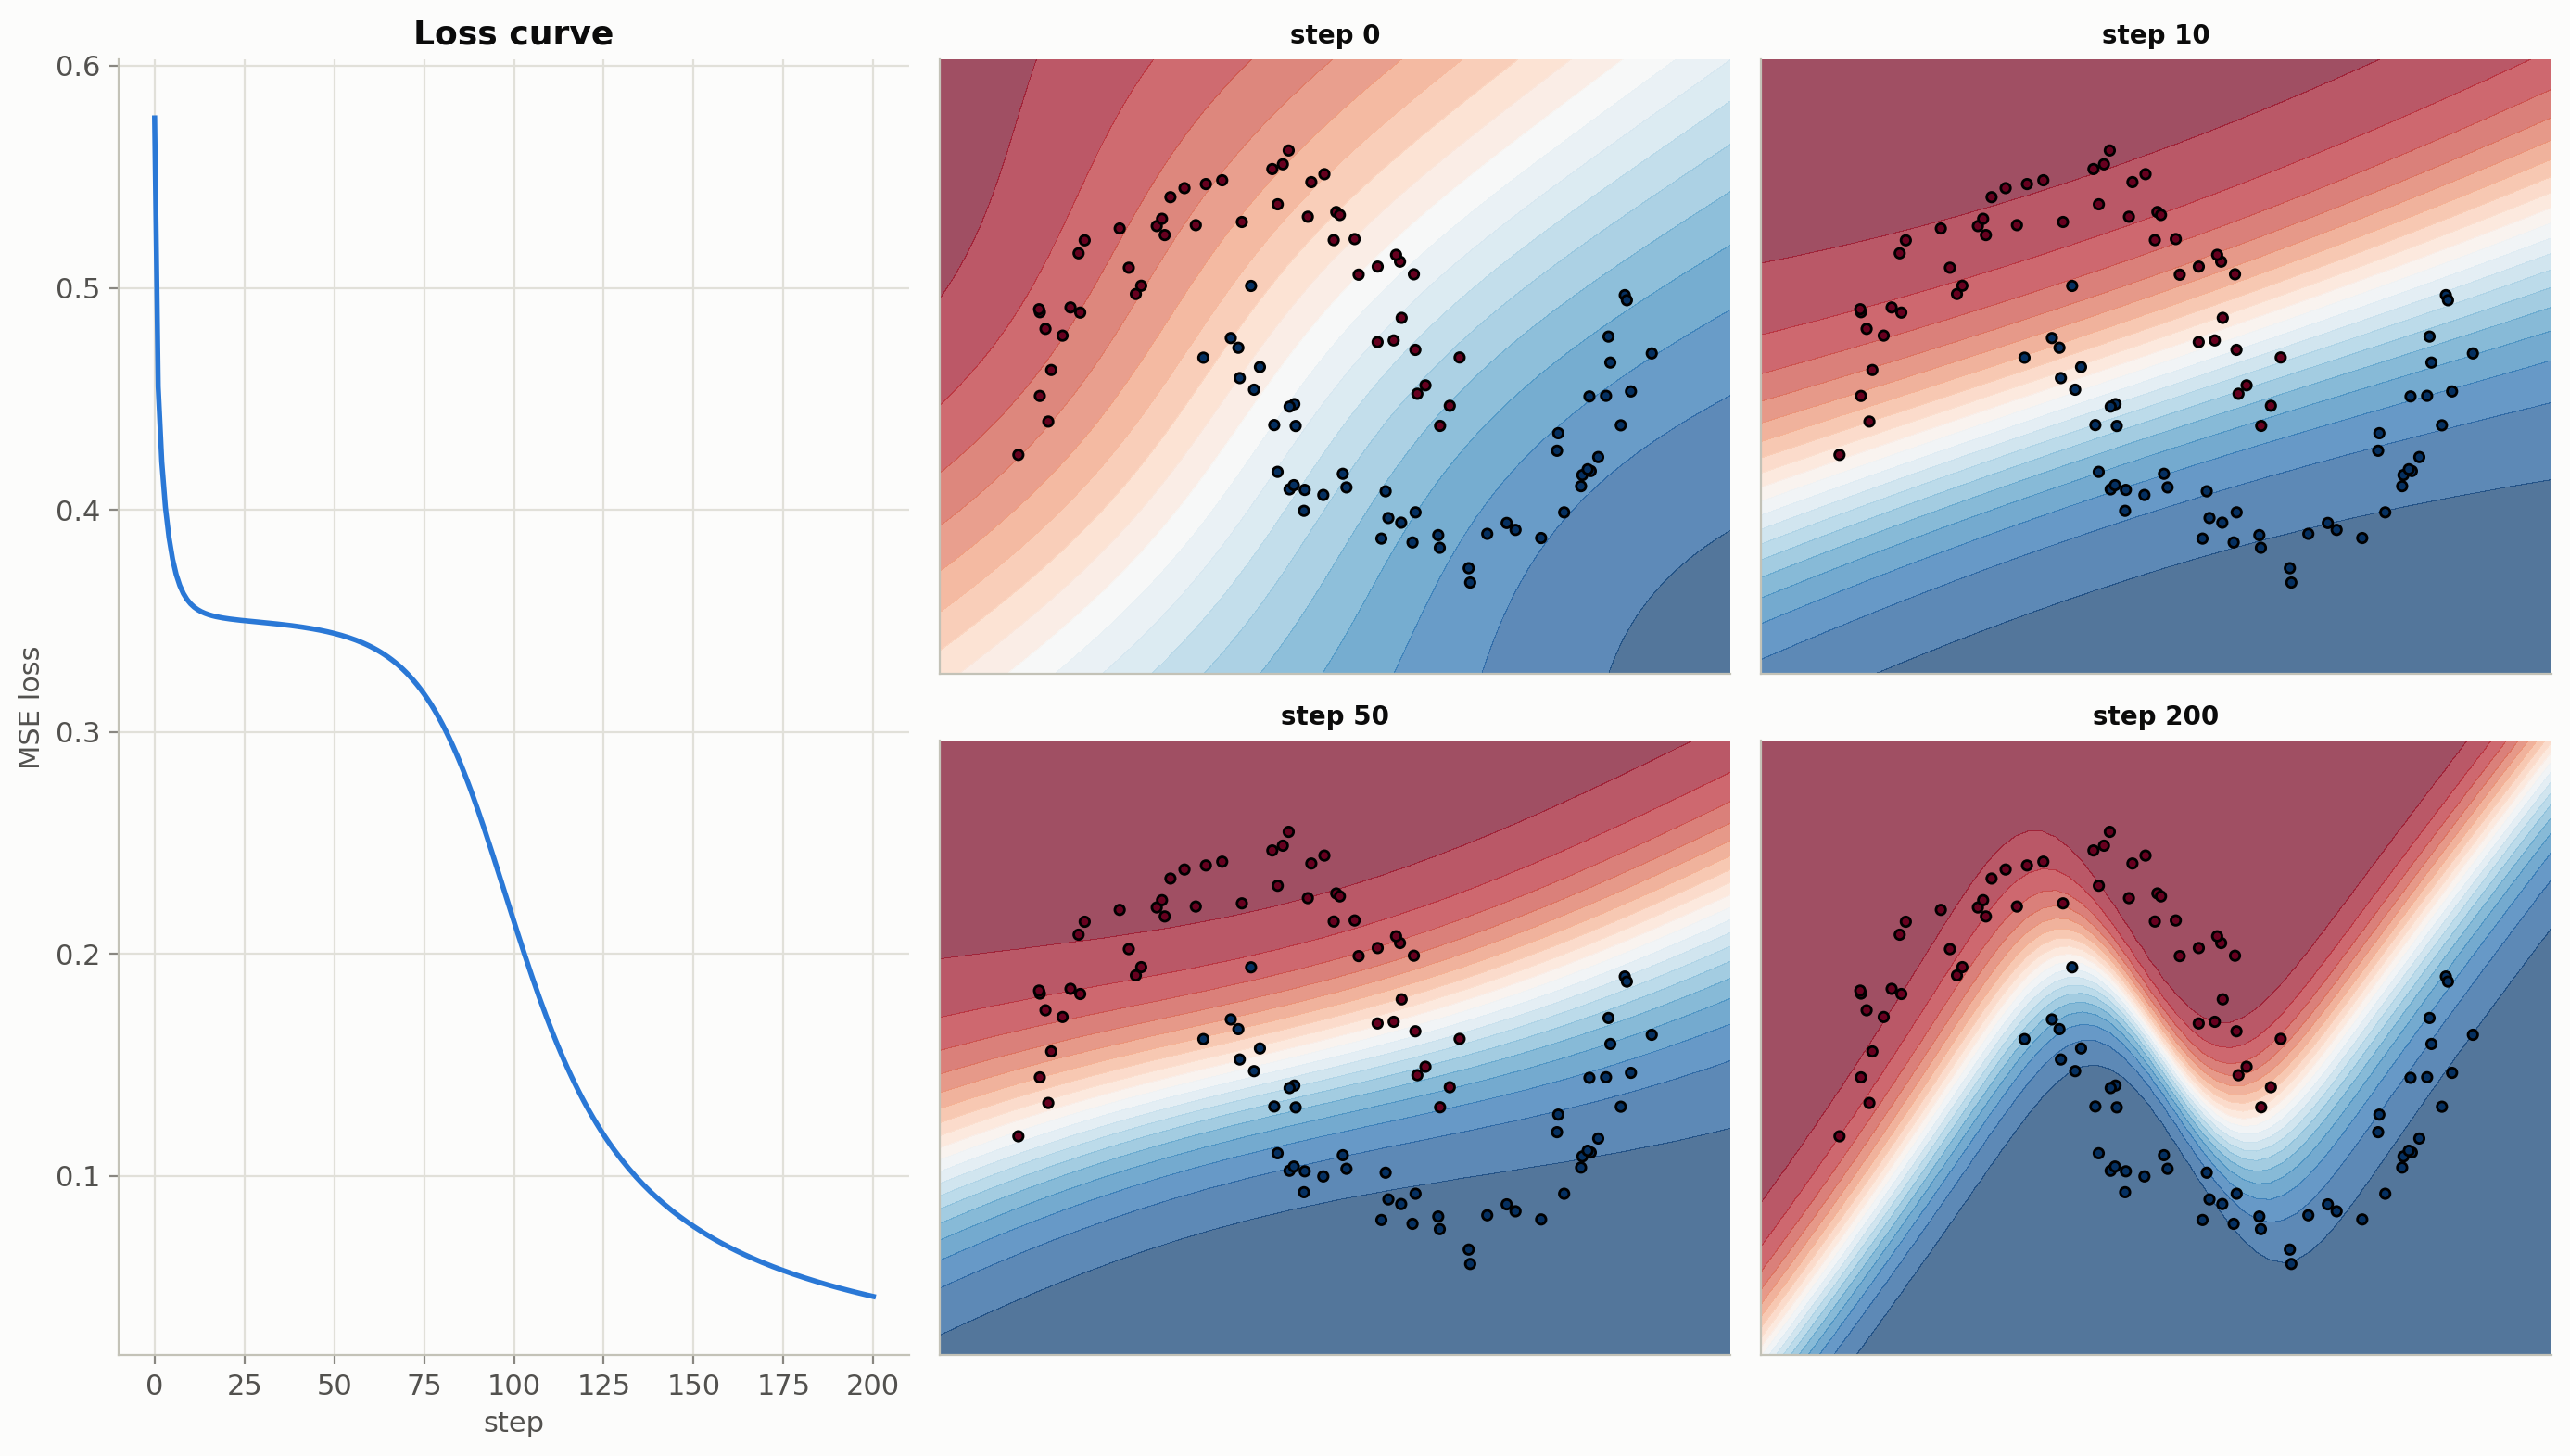

In [5]:
#| code-fold: true
#| code-summary: "Plot: loss curve and the boundary taking shape"
# Re-train with the same seed, capturing boundary grids at the snapshot steps.
snap_steps = [0, 10, 50, 200]
model = MLP(2, [8, 1], seed=1)
gx, gy = np.meshgrid(np.linspace(X[:, 0].min() - 0.4, X[:, 0].max() + 0.4, 60),
                     np.linspace(X[:, 1].min() - 0.4, X[:, 1].max() + 0.4, 60))
grid = np.stack([gx.ravel(), gy.ravel()], axis=1)
grids = {}
for step in range(201):
    if step in snap_steps:
        grids[step] = np.array([model([*g]).tanh().data for g in grid]).reshape(gx.shape)
    loss = batch_loss(model, X, targets)
    model.zero_grad(); loss.backward()
    for p in model.parameters():
        p.data -= 0.5 * p.grad

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(2, 3, (1, 4))
ax.plot(losses)
ax.set_xlabel('step'); ax.set_ylabel('MSE loss'); ax.set_title('Loss curve')
for i, step in enumerate(snap_steps):
    ax = fig.add_subplot(2, 3, [2, 3, 5, 6][i])
    ax.contourf(gx, gy, grids[step], levels=20, cmap='RdBu', alpha=0.7)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', s=14)
    ax.set_title(f'step {step}', fontsize=10); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## 3. The learning rate: the one knob you always tune

Same model, same data, three learning rates. Too small and nothing visibly happens in the
budget; too large and each step overshoots the minimum it aims at — here the overshoot
slams the tanh neurons into saturation and the loss settles *worse than it started*
(with an unbounded loss it would explode outright). Every real run you'll do (including
milestone M5's schedule sweep on your own model) is a negotiation with this plot:

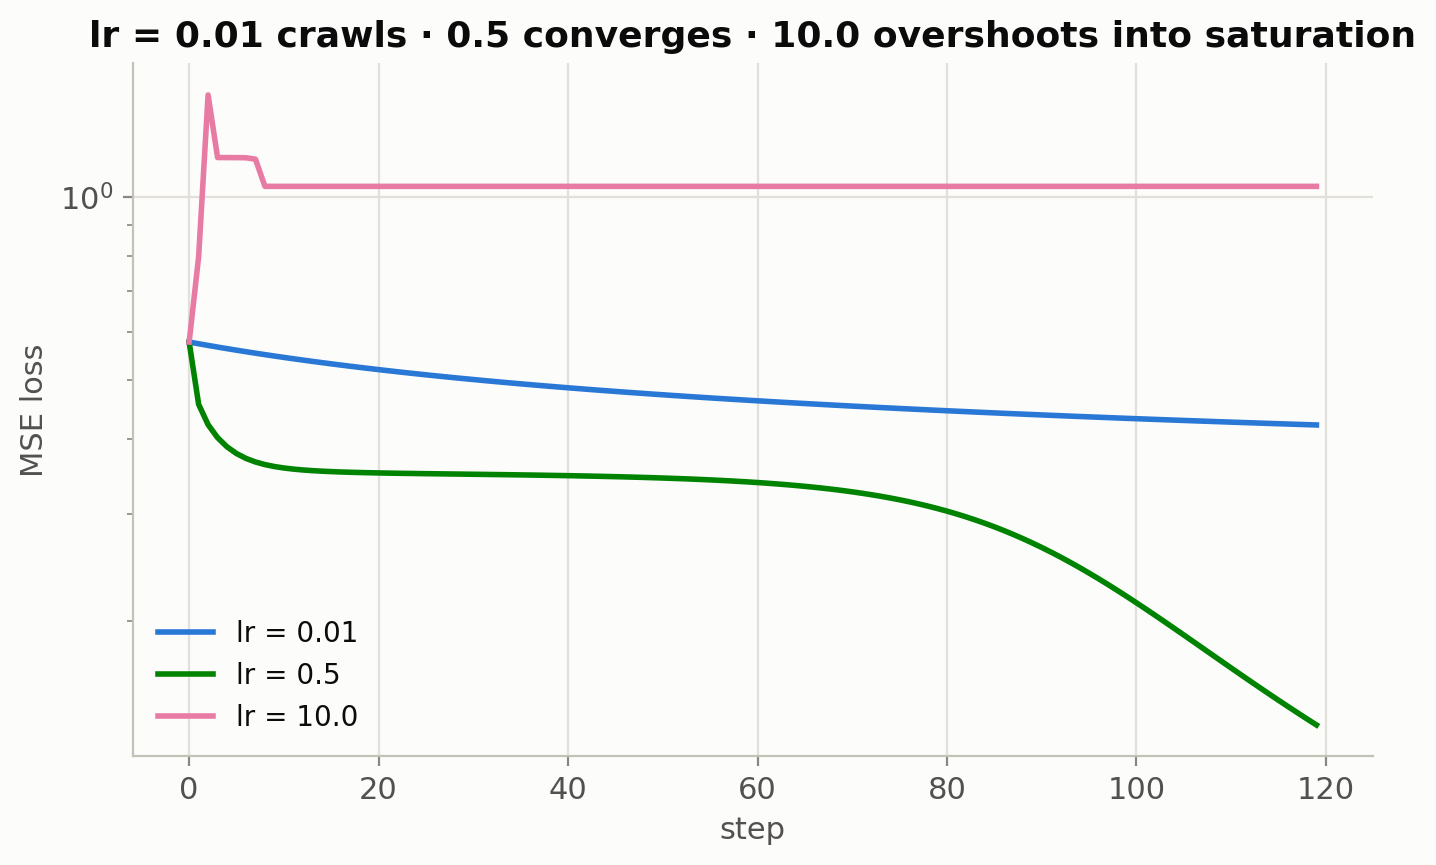

In [6]:
plt.figure(figsize=(8, 4.5))
for lr in [0.01, 0.5, 10.0]:
    m = MLP(2, [8, 1], seed=1)
    curve = []
    for step in range(120):
        loss = batch_loss(m, X, targets)
        curve.append(loss.data)
        m.zero_grad(); loss.backward()
        for p in m.parameters():
            p.data -= lr * p.grad
    plt.plot(curve, label=f'lr = {lr}')
plt.xlabel('step'); plt.ylabel('MSE loss'); plt.yscale('log')
plt.legend(); plt.title('lr = 0.01 crawls · 0.5 converges · 10.0 overshoots into saturation')
plt.show()

## 4. Minibatches: noisier steps, more of them

Full-batch descent computes the exact gradient — of a loss you only care about
approximately. **Stochastic** gradient descent estimates it from a small random batch:
each step is noisy, but you take 10 steps for the price of one, and the noise even helps
escape flat regions. At LLM scale there is no choice: "full batch" would be the entire
internet per step.

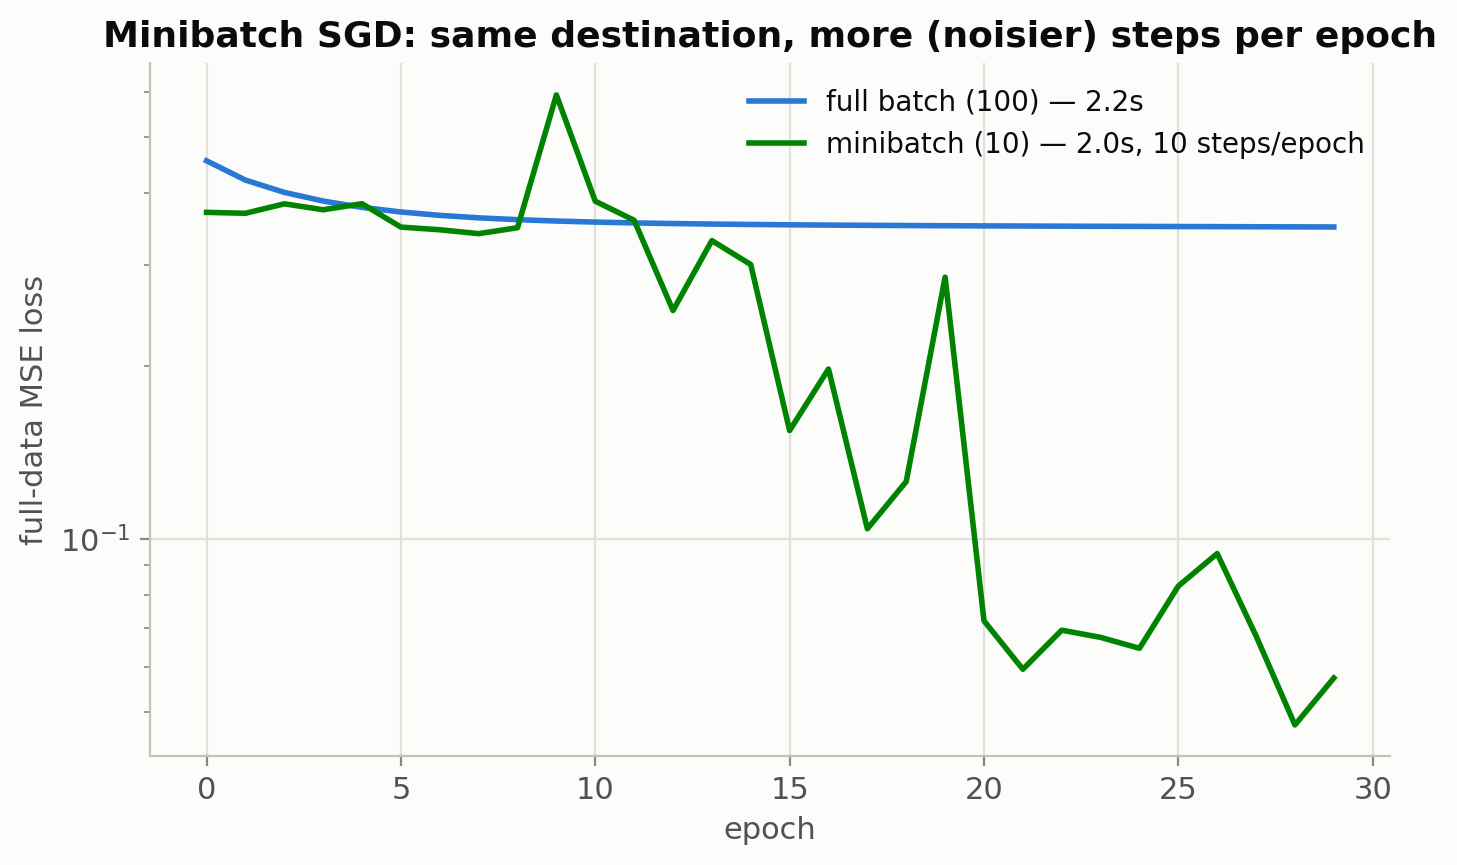

Same 30 epochs: the minibatch run took 10x more steps (300 vs 30), each computed on 1/10th of the data.


In [7]:
def sgd_run(batch_size, epochs=30, lr=0.5, seed=1):
    m = MLP(2, [8, 1], seed=seed)
    r = np.random.default_rng(0)
    curve = []
    for _ in range(epochs):
        order = r.permutation(len(X))
        for start in range(0, len(X), batch_size):
            idx = order[start:start + batch_size]
            loss = batch_loss(m, X[idx], targets[idx])
            m.zero_grad(); loss.backward()
            for p in m.parameters():
                p.data -= lr * p.grad
        curve.append(batch_loss(m, X, targets).data)   # full-data loss, once per epoch
    return curve

t0 = time.perf_counter(); full = sgd_run(batch_size=100); t_full = time.perf_counter() - t0
t0 = time.perf_counter(); mini = sgd_run(batch_size=10); t_mini = time.perf_counter() - t0

plt.figure(figsize=(8, 4.5))
plt.plot(full, label=f'full batch (100) — {t_full:.1f}s')
plt.plot(mini, label=f'minibatch (10) — {t_mini:.1f}s, 10 steps/epoch')
plt.xlabel('epoch'); plt.ylabel('full-data MSE loss'); plt.yscale('log'); plt.legend()
plt.title('Minibatch SGD: same destination, more (noisier) steps per epoch')
plt.show()
print(f'Same {len(full)} epochs: the minibatch run took 10x more steps '
      f'({len(mini) * 10} vs {len(full)}), each computed on 1/10th of the data.')

## 5. The PyTorch bridge

The same architecture and loop in PyTorch — `nn.Sequential` for the layers,
`optim.SGD` wrapping the `p.data -= lr * p.grad` line, `zero_grad()` playing itself.
Overlaid loss curves land on top of each other; the wall-clock does not, and that gap
*is* the vectorization story from chapter 01:

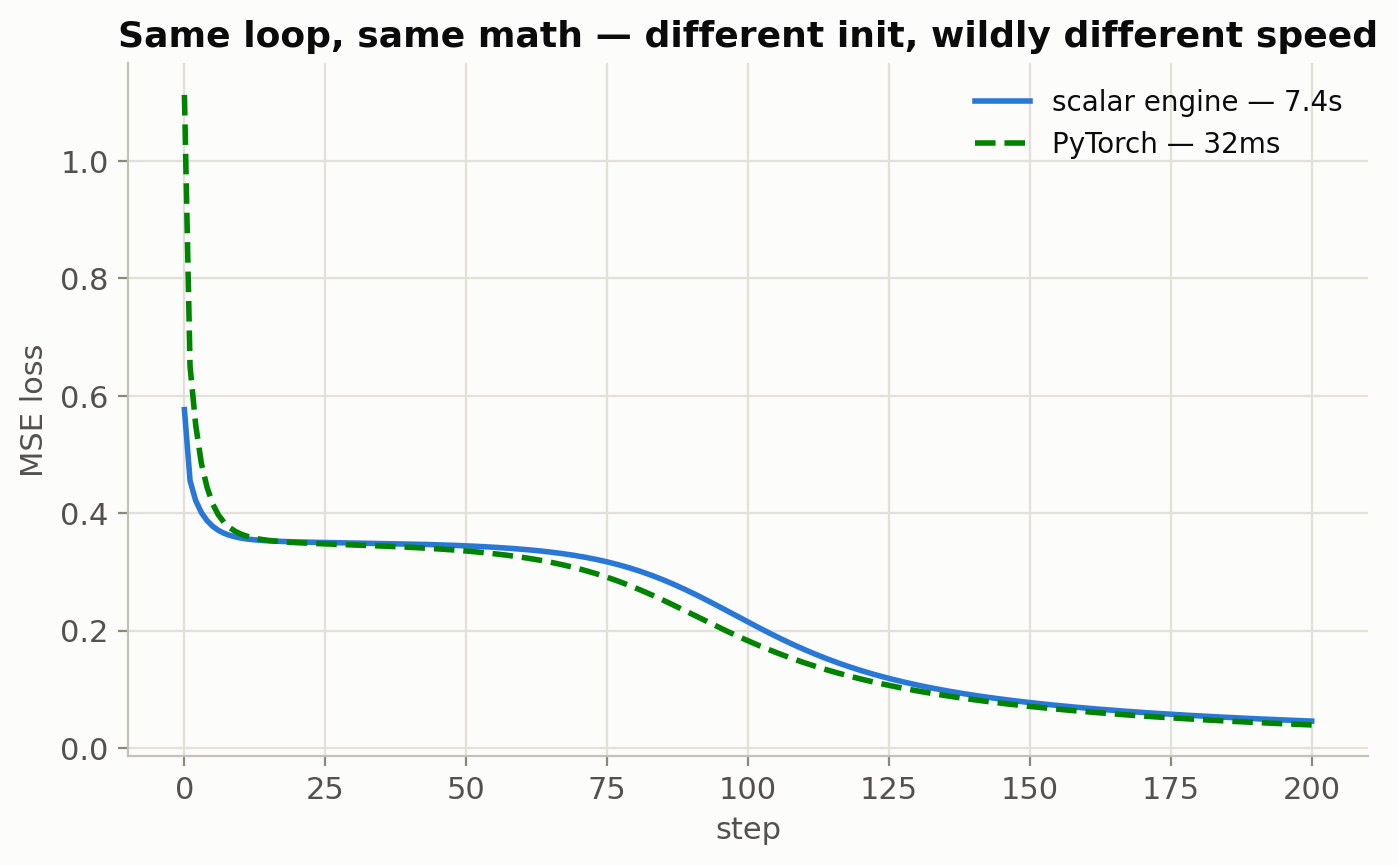

PyTorch is ~233x faster here: same 201 steps, tensors instead of Python floats.


In [8]:
tmodel = torch.nn.Sequential(torch.nn.Linear(2, 8), torch.nn.Tanh(),
                             torch.nn.Linear(8, 1), torch.nn.Tanh())
opt = torch.optim.SGD(tmodel.parameters(), lr=0.5)
tX = torch.tensor(X, dtype=torch.float32)
tt = torch.tensor(targets, dtype=torch.float32)

torch_curve = []
t0 = time.perf_counter()
for step in range(201):
    loss = ((tmodel(tX).squeeze(1) - tt) ** 2).mean()
    torch_curve.append(loss.item())
    opt.zero_grad(); loss.backward(); opt.step()
torch_seconds = time.perf_counter() - t0

plt.figure(figsize=(8, 4.5))
plt.plot(losses, label=f'scalar engine — {scalar_seconds:.1f}s')
plt.plot(torch_curve, '--', label=f'PyTorch — {torch_seconds * 1000:.0f}ms')
plt.xlabel('step'); plt.ylabel('MSE loss'); plt.legend()
plt.title('Same loop, same math — different init, wildly different speed')
plt.show()
print(f'PyTorch is ~{scalar_seconds / torch_seconds:.0f}x faster here: '
      'same 201 steps, tensors instead of Python floats.')

## Key Takeaways

1. **Training is five lines**: forward, `zero_grad`, `backward`, step, repeat. Everything
   in `training/trainer.py` — and every trick in Phase 2 — is an upgrade to one of them.
2. **`zero_grad()` is not optional**: chapter 01's accumulating gradients are a feature
   (gradient accumulation uses it deliberately) that becomes a bug if you forget the reset.
3. **The learning rate has three regimes** — crawl, converge, diverge — and the loss
   curve tells you which one you're in at a glance.
4. **Minibatch SGD trades gradient exactness for step count**, and wins. Batch size is a
   *systems* knob as much as a statistics one — that tension returns in
   [Gradient Accumulation](../02_training_optimization/03_gradient_accumulation.ipynb).
5. **Concrete numbers**: 201 full-batch steps of a 33-parameter MLP on 100 points — a few
   seconds on the scalar engine, milliseconds in PyTorch (the printed ratio above, typically
   two to three orders of magnitude). Same math; tensors.
6. MSE on ±1 targets worked, but it was the wrong loss for classification. Why, and what
   the right one's gradient looks like:
   [Softmax & Cross-Entropy](03_softmax_crossentropy.ipynb) — with milestone **M0**.